# Assignment 4 · Sports Analytics
**IPL Analytics — Player Performance Intelligence**

Evaluating batting, bowling, and all-rounder value for team selection

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110


## 1. Load the Dataset

In [2]:
# Chris Gayle row has an extra comma — skip bad lines, then add him back manually
df = pd.read_csv('ipl_players.csv', on_bad_lines='skip')

# Re-insert Chris Gayle with corrected data (extra empty field removed)
gayle = {
    'player_id': 'PL013', 'player_name': 'Chris Gayle', 'team': 'Punjab Kings',
    'role': 'Batsman', 'nationality': 'West Indian', 'age': 44,
    'matches_played': 142, 'innings_batted': 138, 'runs_scored': 4965,
    'highest_score': 175, 'batting_avg': 40.2, 'strike_rate': 148.9,
    'centuries': np.nan,          # data-entry error — will fill with median
    'half_centuries': 34, 'fours': 380, 'sixes': 320,
    'innings_bowled': 0, 'wickets': 0,
    'bowling_avg': np.nan, 'economy_rate': np.nan, 'best_bowling': np.nan,
    'catches': 42, 'stumpings': 0, 'salary_cr': 13.0, 'mvp_awards': 1
}
df = pd.concat([df, pd.DataFrame([gayle])], ignore_index=True)
df['centuries'] = pd.to_numeric(df['centuries'], errors='coerce')  # ensure numeric

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (30, 25)


,player_id,player_name,team,role,nationality,age,matches_played,innings_batted,runs_scored,highest_score,...,sixes,innings_bowled,wickets,bowling_avg,economy_rate,best_bowling,catches,stumpings,salary_cr,mvp_awards
0,PL001,Rohit Sharma,Mumbai Indians,Batsman,Indian,36,230,225,5880,109,...,285,0,0,NaN,NaN,NaN,45,0,18.5,3
1,PL002,Virat Kohli,Royal Challengers Bangalore,Batsman,Indian,35,237,230,7263,113,...,210,0,0,NaN,NaN,NaN,98,0,21.0,5
2,PL003,MS Dhoni,Chennai Super Kings,Wicket-Keeper,Indian,42,250,185,4978,84,...,220,0,0,NaN,NaN,NaN,165,42,20.0,4
3,PL004,Jasprit Bumrah,Mumbai Indians,Bowler,Indian,30,120,15,85,22,...,5,118,145,22.8,6.8,5/10,35,0,17.5,2
4,PL005,KL Rahul,Lucknow Super Giants,Batsman,Indian,31,132,128,4200,132,...,190,0,0,NaN,NaN,NaN,52,18,19.5,1


In [ ]:
# top_value = (df[batting_mask][['player_name', 'role', 'runs_scored', 'salary_cr', 'performance_per_crore']]    important
#              .sort_values('performance_per_crore', ascending=False)
#              .head(5))


## 2. Identify All NaN Columns

In [3]:
# Use isnull().sum() to identify NaN columns
nan_summary = df.isnull().sum()
print("NaN counts per column:")
print(nan_summary[nan_summary > 0])


NaN counts per column:
centuries        1
bowling_avg     15
economy_rate    15
best_bowling    15
dtype: int64


## 3. Handle Missing Values

In [4]:
# (a) stumpings NaN → fill with 0 for non-keepers (already 0 here, but explicit)
df['stumpings'] = df['stumpings'].fillna(0)

# (b) centuries: fill Chris Gayle's NaN with median centuries of Batsmen only
batsman_mask = df['role'] == 'Batsman'
median_centuries = df.loc[batsman_mask, 'centuries'].median()
print(f"Median centuries (Batsmen): {median_centuries}")
df.loc[batsman_mask, 'centuries'] = df.loc[batsman_mask, 'centuries'].fillna(median_centuries)

# https://copilot.microsoft.com/shares/3rHTDKn4ahgAtDWSHerr3

# (c) bowling_avg, economy_rate, best_bowling — do NOT fill globally
#     These are legitimately NaN for non-bowlers; leave as-is
print("\nNaN counts after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# https://copilot.microsoft.com/shares/A1jWmAgBBihQcbXeEKznF


Median centuries (Batsmen): 2.0

NaN counts after cleaning:
bowling_avg     15
economy_rate    15
best_bowling    15
dtype: int64


## 4. Derived Column: `performance_per_crore`

For batting players (Batsman + All-Rounder + Wicket-Keeper):  
`performance_per_crore = runs_scored / salary_cr`

In [17]:
batting_roles = ['Batsman', 'All-Rounder', 'Wicket-Keeper']
batting_mask = df['role'].isin(batting_roles)

df['performance_per_crore'] = np.nan
df.loc[batting_mask, 'performance_per_crore'] = (
    df.loc[batting_mask, 'runs_scored'] / df.loc[batting_mask, 'salary_cr']
)

# https://copilot.microsoft.com/shares/y4BmRpKM2aTHvLw9dHQmC

# Top 5 value-for-money batting players
top_value = (df[batting_mask][['player_name', 'role', 'runs_scored', 'salary_cr', 'performance_per_crore']]
             .sort_values('performance_per_crore', ascending=False)
             .head(5))
print("Best value batting players (runs per crore of salary):")
top_value


Best value batting players (runs per crore of salary):


,player_name,role,runs_scored,salary_cr,performance_per_crore
14,Shikhar Dhawan,Batsman,6244,13.5,462.518519
9,Suresh Raina,All-Rounder,5528,12.0,460.666667
29,Chris Gayle,Batsman,4965,13.0,381.923077
7,David Warner,Batsman,5881,16.0,367.562500
20,Dinesh Karthik,Wicket-Keeper,4200,11.5,365.217391


In [16]:
df.loc[batting_mask, 'runs_scored']

0     5880
1     7263
2     4978
4     4200
5     2650
7     5881
8     4849
9     5528
11    2838
12    2350
14    6244
15    2502
16    3412
18    2500
19     820
20    4200
22    3800
23    3800
24    2950
26    2650
27    1250
28    2850
29    4965
Name: runs_scored, dtype: int64

In [15]:
df.head()

,player_id,player_name,team,role,nationality,age,matches_played,innings_batted,runs_scored,highest_score,...,innings_bowled,wickets,bowling_avg,economy_rate,best_bowling,catches,stumpings,salary_cr,mvp_awards,performance_per_crore
0,PL001,Rohit Sharma,Mumbai Indians,Batsman,Indian,36,230,225,5880,109,...,0,0,NaN,NaN,NaN,45,0,18.5,3,317.837838
1,PL002,Virat Kohli,Royal Challengers Bangalore,Batsman,Indian,35,237,230,7263,113,...,0,0,NaN,NaN,NaN,98,0,21.0,5,345.857143
2,PL003,MS Dhoni,Chennai Super Kings,Wicket-Keeper,Indian,42,250,185,4978,84,...,0,0,NaN,NaN,NaN,165,42,20.0,4,248.900000
3,PL004,Jasprit Bumrah,Mumbai Indians,Bowler,Indian,30,120,15,85,22,...,118,145,22.8,6.8,5/10,35,0,17.5,2,NaN
4,PL005,KL Rahul,Lucknow Super Giants,Batsman,Indian,31,132,128,4200,132,...,0,0,NaN,NaN,NaN,52,18,19.5,1,215.384615


## 5. Salary Statistics by Role

Mean, median, variance, and standard deviation of `salary_cr` for each player role.

In [18]:
salary_stats = df.groupby('role')['salary_cr'].agg(
    Mean='mean', Median='median', Variance='var', Std_Dev='std'
).round(2)

print(salary_stats)
print(f"\nRole with highest salary variation (std dev): {salary_stats['Std_Dev'].idxmax()}")

# https://copilot.microsoft.com/shares/UpEnr8jALsE5pwY8sCmnL


                Mean  Median  Variance  Std_Dev
role                                           
All-Rounder    14.06   14.00      6.60     2.57
Batsman        16.44   16.00      7.78     2.79
Bowler         14.43   14.50     13.87     3.72
Wicket-Keeper  15.25   15.25      8.87     2.98

Role with highest salary variation (std dev): Bowler


## 6. Best & Worst Bowlers

Among Bowlers only:  
- Lowest `bowling_avg` = best (fewer runs conceded per wicket)  
- Lowest `economy_rate` = best (fewer runs per over)

In [21]:
bowlers = df[df['role'] == 'Bowler'].copy()

# https://copilot.microsoft.com/shares/wXSpRZtWWjUtUPkyqJFkE

best_avg    = bowlers.loc[bowlers['bowling_avg'].idxmin(), ['player_name', 'bowling_avg']]

# https://copilot.microsoft.com/shares/fe58NZ9bag1WZaiueefyj

worst_avg   = bowlers.loc[bowlers['bowling_avg'].idxmax(), ['player_name', 'bowling_avg']]
best_econ   = bowlers.loc[bowlers['economy_rate'].idxmin(), ['player_name', 'economy_rate']]
worst_econ  = bowlers.loc[bowlers['economy_rate'].idxmax(), ['player_name', 'economy_rate']]

print("Best bowling average (lowest):", best_avg['player_name'], "—", best_avg['bowling_avg'])
print("Worst bowling average (highest):", worst_avg['player_name'], "—", worst_avg['bowling_avg'])
print()
print("Best economy rate (lowest):", best_econ['player_name'], "—", best_econ['economy_rate'])
print("Worst economy rate (highest):", worst_econ['player_name'], "—", worst_econ['economy_rate'])


Best bowling average (lowest): Rashid Khan — 19.6
Worst bowling average (highest): Pat Cummins — 28.4

Best economy rate (lowest): Rashid Khan — 6.2
Worst economy rate (highest): Mohammed Shami — 8.5


In [19]:
df['role'] == 'Bowler'

0     False
1     False
2     False
3      True
4     False
5     False
6      True
7     False
8     False
9     False
10     True
11    False
12    False
13     True
14    False
15    False
16    False
17     True
18    False
19    False
20    False
21     True
22    False
23    False
24    False
25     True
26    False
27    False
28    False
29    False
Name: role, dtype: bool

## 7. Mean Batting Average & Strike Rate by Nationality

Do Indian or Overseas players perform better on average?

In [8]:
# Only batting players have meaningful batting_avg
batting_df = df[batting_mask].copy()

nat_stats = batting_df.groupby('nationality')[['batting_avg', 'strike_rate']].mean().round(2)
nat_stats.columns = ['Avg Batting Average', 'Avg Strike Rate']
print(nat_stats.to_string())
print()
print("Higher batting avg:", nat_stats['Avg Batting Average'].idxmax())
print("Higher strike rate:", nat_stats['Avg Strike Rate'].idxmax())


               Avg Batting Average  Avg Strike Rate
nationality                                        
Australian                   35.50           151.80
English                      22.15           132.00
Indian                       32.47           136.41
South African                35.50           139.33
West Indian                  35.43           160.93

Higher batting avg: Australian
Higher strike rate: West Indian


## 8. Team with Highest Total Salary & Highest Average Runs per Player

In [9]:
team_stats = df.groupby('team').agg(
    Total_Salary=('salary_cr', 'sum'),
    Avg_Runs_Per_Player=('runs_scored', 'mean')
).round(2)

highest_salary_team = team_stats['Total_Salary'].idxmax()
highest_runs_team   = team_stats['Avg_Runs_Per_Player'].idxmax()

print(f"Team with highest total salary expenditure: {highest_salary_team} "
      f"(₹{team_stats.loc[highest_salary_team,'Total_Salary']} Cr)")
print(f"Team with highest average runs per player:  {highest_runs_team} "
      f"({team_stats.loc[highest_runs_team,'Avg_Runs_Per_Player']:.1f} runs)")
print()
print(team_stats.sort_values('Total_Salary', ascending=False).to_string())


Team with highest total salary expenditure: Mumbai Indians (₹78.5 Cr)
Team with highest average runs per player:  Royal Challengers Bangalore (4612.4 runs)

                             Total_Salary  Avg_Runs_Per_Player
team                                                          
Mumbai Indians                       78.5              2905.40
Royal Challengers Bangalore          78.0              4612.40
Chennai Super Kings                  56.0              3564.50
Delhi Capitals                       47.5              2912.33
Punjab Kings                         45.0              4009.67
Gujarat Titans                       43.0               970.00
Rajasthan Royals                     38.0              1278.00
Kolkata Knight Riders                34.5              1192.50
Lucknow Super Giants                 32.5              3425.00


## 9. Matplotlib Scatter Plot: Salary vs Runs Scored

Labels shown for the top 5 earners.

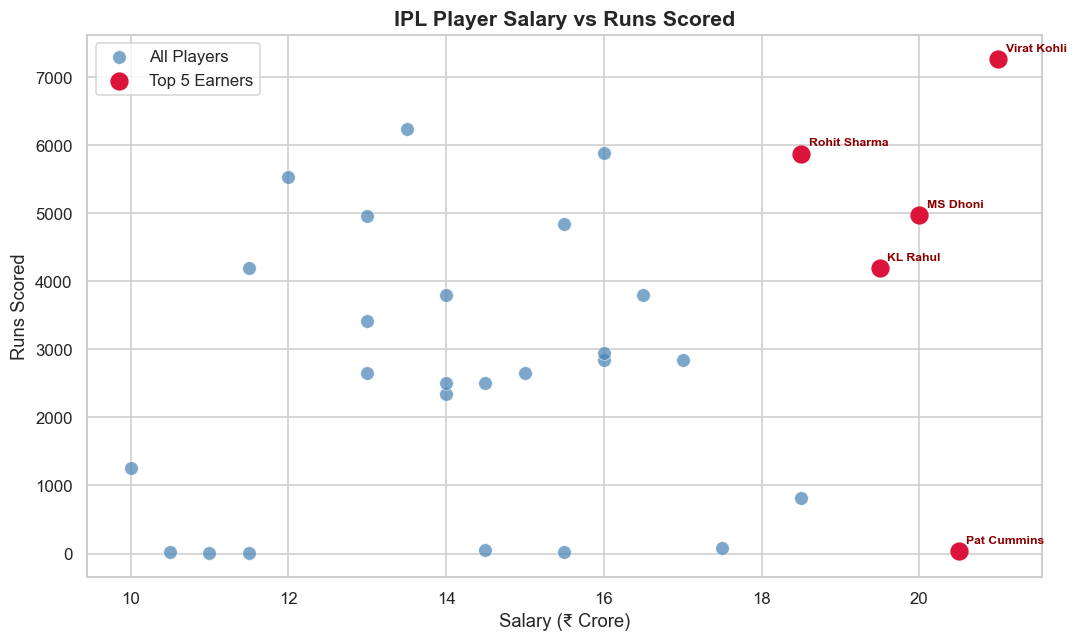

Figure saved as scatter_salary_vs_runs.png


In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

# All players
ax.scatter(df['salary_cr'], df['runs_scored'], color='steelblue', alpha=0.7,
           edgecolors='white', linewidths=0.5, s=80, label='All Players')

# Top 5 earners
top5_earners = df.nlargest(5, 'salary_cr')
ax.scatter(top5_earners['salary_cr'], top5_earners['runs_scored'],
           color='crimson', s=120, zorder=5, label='Top 5 Earners')

for _, row in top5_earners.iterrows():
    ax.annotate(row['player_name'],
                xy=(row['salary_cr'], row['runs_scored']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, color='darkred', fontweight='bold')

ax.set_xlabel('Salary (₹ Crore)', fontsize=12)
ax.set_ylabel('Runs Scored', fontsize=12)
ax.set_title('IPL Player Salary vs Runs Scored', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('scatter_salary_vs_runs.png', dpi=120)
plt.show()
print("Figure saved as scatter_salary_vs_runs.png")


## 10. Seaborn Bar Chart: Average MVP Awards per Player Role

Which role wins the most Man of the Match awards?

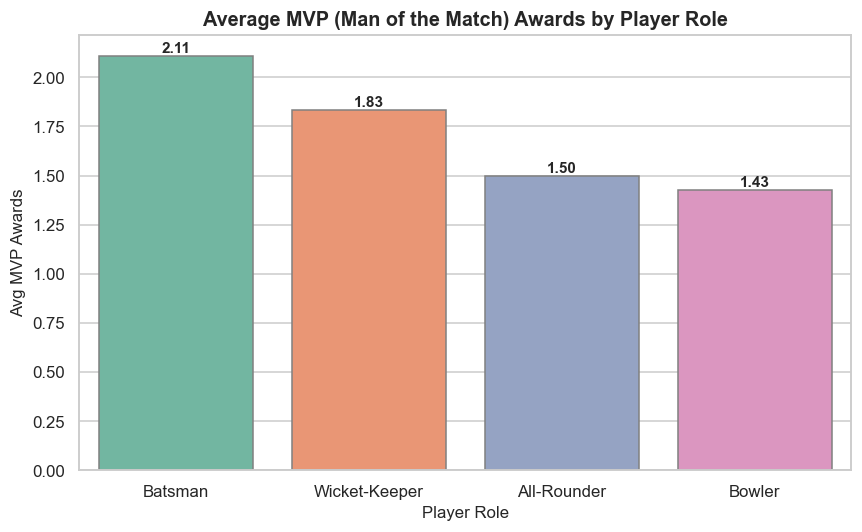

Role that wins the most MoM awards: Batsman


In [11]:
avg_mvp = df.groupby('role')['mvp_awards'].mean().reset_index()
avg_mvp.columns = ['Role', 'Avg MVP Awards']
avg_mvp = avg_mvp.sort_values('Avg MVP Awards', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=avg_mvp, x='Role', y='Avg MVP Awards',
            palette='Set2', edgecolor='grey', ax=ax)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Average MVP (Man of the Match) Awards by Player Role',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Player Role', fontsize=11)
ax.set_ylabel('Avg MVP Awards', fontsize=11)
plt.tight_layout()
plt.savefig('bar_mvp_by_role.png', dpi=120)
plt.show()

best_role = avg_mvp.iloc[0]['Role']
print(f"Role that wins the most MoM awards: {best_role}")


## 11. Experience Effect: Players Aged 30+ vs Under 30

Does experience lead to better batting average?

In [12]:
# Only batting players with valid batting_avg
bat_df = df[batting_mask].dropna(subset=['batting_avg']).copy()
bat_df['age_group'] = bat_df['age'].apply(lambda x: '30+' if x >= 30 else 'Under 30')

age_stats = bat_df.groupby('age_group')['batting_avg'].agg(['mean', 'count']).round(2)
age_stats.columns = ['Avg Batting Average', 'Player Count']
print(age_stats)

senior_avg = age_stats.loc['30+', 'Avg Batting Average']
junior_avg = age_stats.loc['Under 30', 'Avg Batting Average']

if senior_avg > junior_avg:
    print(f"\nYes — experienced players (30+) average {senior_avg:.1f} vs {junior_avg:.1f} for under-30s.")
else:
    print(f"\nNo — younger players (<30) average {junior_avg:.1f} vs {senior_avg:.1f} for 30+.")


           Avg Batting Average  Player Count
age_group                                   
30+                      33.07            18
Under 30                 31.00             5

Yes — experienced players (30+) average 33.1 vs 31.0 for under-30s.


## 12. Insight Report

### Which 3 players offer the best value for money?

In [13]:
# Best value = highest performance_per_crore among batting players
best_3_value = (df[batting_mask][['player_name', 'team', 'role', 'runs_scored',
                                   'salary_cr', 'performance_per_crore']]
                .sort_values('performance_per_crore', ascending=False)
                .head(3))

print("=== TOP 3 VALUE-FOR-MONEY PLAYERS ===")
for i, row in best_3_value.iterrows():
    print(f"  {row['player_name']} ({row['team']}, {row['role']}): "
          f"{row['runs_scored']} runs @ ₹{row['salary_cr']} Cr → "
          f"{row['performance_per_crore']:.1f} runs/crore")

# Best balanced team = team with players across all 4 roles
print("\n=== MOST BALANCED TEAM (all roles covered) ===")
team_roles = df.groupby('team')['role'].nunique().sort_values(ascending=False)
print(team_roles)
best_team = team_roles.idxmax()
print(f"\nBest balanced team: {best_team} ({team_roles[best_team]} distinct roles)")


=== TOP 3 VALUE-FOR-MONEY PLAYERS ===
  Shikhar Dhawan (Punjab Kings, Batsman): 6244 runs @ ₹13.5 Cr → 462.5 runs/crore
  Suresh Raina (Chennai Super Kings, All-Rounder): 5528 runs @ ₹12.0 Cr → 460.7 runs/crore
  Chris Gayle (Punjab Kings, Batsman): 4965 runs @ ₹13.0 Cr → 381.9 runs/crore

=== MOST BALANCED TEAM (all roles covered) ===
team
Mumbai Indians                 4
Royal Challengers Bangalore    3
Delhi Capitals                 3
Chennai Super Kings            2
Gujarat Titans                 2
Lucknow Super Giants           2
Kolkata Knight Riders          2
Punjab Kings                   2
Rajasthan Royals               2
Name: role, dtype: int64

Best balanced team: Mumbai Indians (4 distinct roles)


## 13. Full Cleaned Dataset Preview

In [14]:
df.to_csv('ipl_players_cleaned.csv', index=False)
print("Cleaned dataset saved as ipl_players_cleaned.csv")
df[['player_name','team','role','nationality','age','runs_scored','batting_avg',
    'bowling_avg','economy_rate','salary_cr','performance_per_crore','mvp_awards']].round(2)


Cleaned dataset saved as ipl_players_cleaned.csv


,player_name,team,role,nationality,age,runs_scored,batting_avg,bowling_avg,economy_rate,salary_cr,performance_per_crore,mvp_awards
0,Rohit Sharma,Mumbai Indians,Batsman,Indian,36,5880,30.5,NaN,NaN,18.5,317.84,3
1,Virat Kohli,Royal Challengers Bangalore,Batsman,Indian,35,7263,37.1,NaN,NaN,21.0,345.86,5
2,MS Dhoni,Chennai Super Kings,Wicket-Keeper,Indian,42,4978,38.9,NaN,NaN,20.0,248.90,4
3,Jasprit Bumrah,Mumbai Indians,Bowler,Indian,30,85,8.5,22.8,6.8,17.5,NaN,2
4,KL Rahul,Lucknow Super Giants,Batsman,Indian,31,4200,38.5,NaN,NaN,19.5,215.38,1
5,Hardik Pandya,Mumbai Indians,All-Rounder,Indian,30,2650,28.2,28.4,8.2,15.0,176.67,2
6,Rashid Khan,Gujarat Titans,Bowler,Afghan,25,45,5.0,19.6,6.2,14.5,NaN,3
7,David Warner,Delhi Capitals,Batsman,Australian,37,5881,41.2,NaN,NaN,16.0,367.56,2
8,AB de Villiers,Royal Challengers Bangalore,Batsman,South African,39,4849,40.2,NaN,NaN,15.5,312.84,3
9,Suresh Raina,Chennai Super Kings,All-Rounder,Indian,37,5528,32.5,32.5,8.5,12.0,460.67,2
